In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

In [6]:
iris=load_iris()
df=pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)
df['target']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
#feature ve target ayrımı
X=iris.data
y=iris.target

In [10]:
#train_test_split
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [38]:
#karar ağacı modeli oluşturma
tree_clf=DecisionTreeClassifier(criterion="gini",max_depth=3,random_state=42)
tree_clf.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [39]:
#test
y_pred=tree_clf.predict(X_test)


In [40]:
accuracy=accuracy_score(y_pred,y_test)
accuracy

1.0

In [41]:
#confusion matrix
conf_matrix=confusion_matrix(y_pred,y_test)
conf_matrix

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

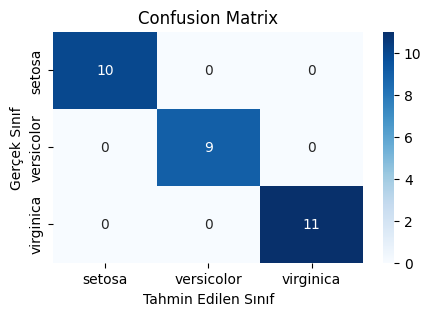

In [42]:
plt.figure(figsize=(5,3))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Confusion Matrix")
plt.show()

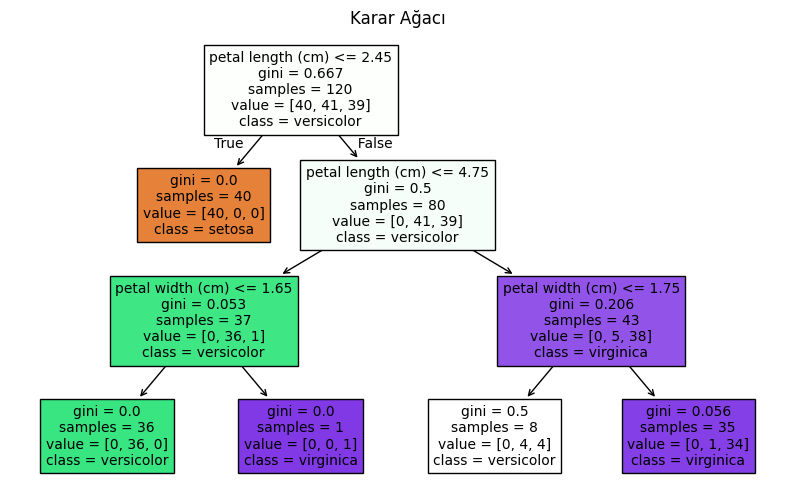

In [43]:
#karar ağacının görselleştirilmesi
plt.figure(figsize=(10,6))
plot_tree(
    tree_clf,
    filled=True,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names)
)
plt.title("Karar Ağacı")
plt.show("Decision Tree Visualization")
plt.show()

In [44]:
#feature importance
feature_importance=tree_clf.feature_importances_
feature_names=iris.feature_names

feature_importance_sorted=sorted(
    zip(feature_importance,feature_names),
    reverse=True
)

print("\nÖznitelik Önem Dereceleri:")
for importance, feature_name in feature_importance_sorted:
    print(f"{feature_name}: {importance:.4f}")


Öznitelik Önem Dereceleri:
petal length (cm): 0.9346
petal width (cm): 0.0654
sepal width (cm): 0.0000
sepal length (cm): 0.0000


KÜMELEME:K-Means Clustering

In [46]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs



In [53]:
#veri seti oluşturma
X,_=make_blobs(n_samples=300, centers=4,cluster_std=0.6,random_state=42)


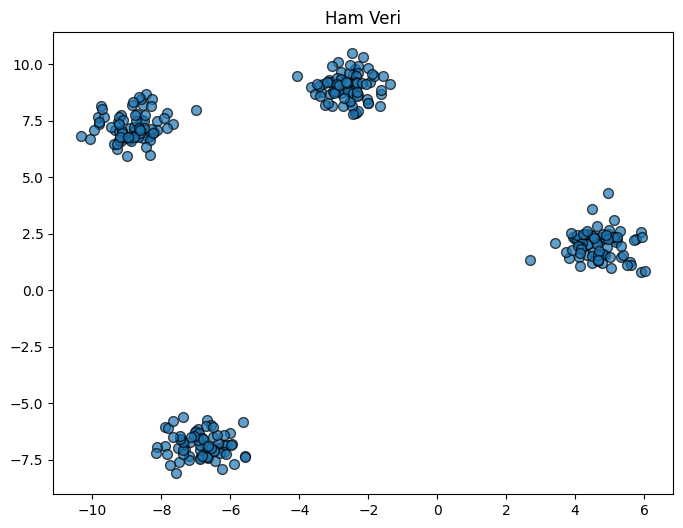

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],s=50,alpha=0.7,edgecolors="k")
plt.title("Ham Veri")
plt.show()

In [57]:
#K_means modelinin tanımlanması ve eğitimi
kmeans=KMeans(n_clusters=4)
kmeans.fit(X)

KMeans(n_clusters=4)

In [59]:
#küme merkezlerini görselleştir

plt.figure()
labels=kmeans.labels_
labels

array([0, 0, 3, 1, 0, 1, 2, 1, 3, 2, 3, 2, 3, 3, 0, 3, 0, 2, 3, 3, 2, 3,
       1, 0, 3, 0, 0, 1, 1, 2, 3, 2, 0, 2, 0, 3, 0, 1, 0, 1, 2, 3, 0, 1,
       3, 3, 0, 2, 0, 2, 1, 0, 1, 3, 1, 2, 0, 2, 2, 3, 0, 2, 2, 0, 1, 1,
       1, 1, 1, 3, 1, 1, 0, 2, 3, 0, 1, 1, 3, 1, 3, 3, 0, 3, 1, 0, 0, 2,
       2, 2, 0, 3, 0, 3, 3, 0, 1, 3, 0, 0, 2, 2, 2, 3, 3, 3, 3, 3, 1, 0,
       2, 3, 3, 3, 3, 2, 0, 1, 0, 1, 1, 1, 3, 0, 1, 0, 0, 3, 0, 1, 2, 3,
       3, 3, 3, 2, 2, 0, 3, 1, 3, 2, 1, 3, 2, 2, 2, 2, 1, 3, 3, 0, 2, 1,
       3, 2, 1, 0, 0, 2, 3, 0, 1, 0, 2, 0, 1, 3, 3, 3, 3, 3, 1, 2, 2, 1,
       1, 2, 2, 1, 0, 3, 0, 2, 2, 0, 1, 3, 2, 2, 1, 1, 1, 0, 2, 1, 1, 2,
       2, 0, 3, 3, 1, 2, 3, 1, 1, 0, 1, 3, 3, 1, 1, 2, 0, 1, 0, 0, 3, 0,
       0, 1, 0, 1, 2, 2, 0, 0, 2, 2, 2, 0, 3, 1, 2, 1, 0, 2, 0, 0, 0, 1,
       1, 2, 0, 1, 1, 1, 0, 1, 0, 1, 0, 2, 1, 0, 2, 3, 0, 3, 2, 3, 0, 3,
       1, 2, 1, 2, 2, 3, 3, 1, 2, 2, 0, 0, 1, 3, 3, 2, 2, 2, 2, 1, 0, 2,
       1, 2, 2, 1, 3, 1, 2, 3, 0, 3, 2, 3, 0, 0], d

<Figure size 640x480 with 0 Axes>

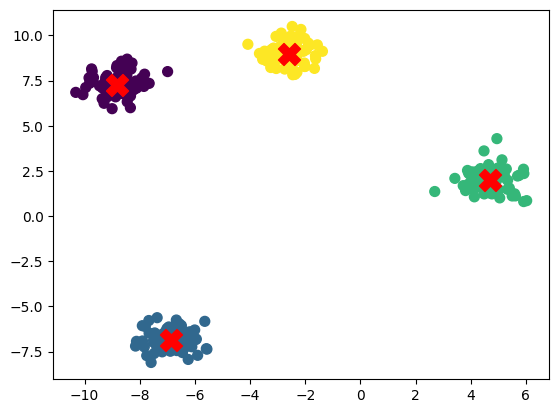

In [62]:
plt.scatter(X[:,0],X[:,1],c=labels, cmap="viridis",s=50)
centers=kmeans.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],c="red",s=250,marker="X")

Hiyerarşik Kümeleme

In [70]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

In [71]:
#veri setini oluşturma
X,_=make_blobs(n_samples=300,centers=4,cluster_std=0.7, random_state=42)



<function matplotlib.pyplot.show(close=None, block=None)>

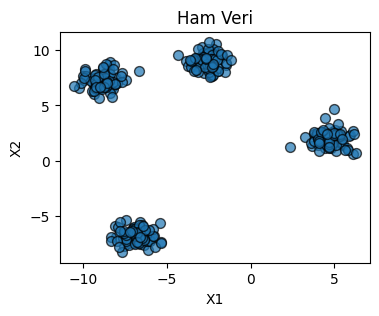

In [74]:
#Ham veriyi görselleştirme
plt.figure(figsize=(4,3))
plt.scatter(X[:,0],X[:,1],s=50, alpha=0.7,edgecolors="k")
plt.title("Ham Veri")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show

In [94]:
#hiyerarşik kümeleme modeli
model=AgglomerativeClustering(n_clusters=4)
model.fit(X)

AgglomerativeClustering(n_clusters=4)

In [95]:
#veri noktalarının ait olduğu kümeleri belirleme
labels=model.fit_predict(X)
labels

array([0, 0, 3, 1, 0, 1, 2, 1, 3, 2, 3, 2, 3, 3, 0, 3, 0, 2, 3, 3, 2, 3,
       1, 0, 3, 0, 0, 1, 1, 2, 3, 2, 0, 2, 0, 3, 0, 1, 0, 1, 2, 3, 0, 1,
       3, 3, 0, 2, 0, 2, 1, 0, 1, 3, 1, 2, 0, 2, 2, 3, 0, 2, 2, 0, 1, 1,
       1, 1, 1, 3, 1, 1, 0, 2, 3, 0, 1, 1, 3, 1, 3, 3, 0, 3, 1, 0, 0, 2,
       2, 2, 0, 3, 0, 3, 3, 0, 1, 3, 0, 0, 2, 2, 2, 3, 3, 3, 3, 3, 1, 0,
       2, 3, 3, 3, 3, 2, 0, 1, 0, 1, 1, 1, 3, 0, 1, 0, 0, 3, 0, 1, 2, 3,
       3, 3, 3, 2, 2, 0, 3, 1, 3, 2, 1, 3, 2, 2, 2, 2, 1, 3, 3, 0, 2, 1,
       3, 2, 1, 0, 0, 2, 3, 0, 1, 0, 2, 0, 1, 3, 3, 3, 3, 3, 1, 2, 2, 1,
       1, 2, 2, 1, 0, 3, 0, 2, 2, 0, 1, 3, 2, 2, 1, 1, 1, 0, 2, 1, 1, 2,
       2, 0, 3, 3, 1, 2, 3, 1, 1, 0, 1, 3, 3, 1, 1, 2, 0, 1, 0, 0, 3, 0,
       0, 1, 0, 1, 2, 2, 0, 0, 2, 2, 2, 0, 3, 1, 2, 1, 0, 2, 0, 0, 0, 1,
       1, 2, 0, 1, 1, 1, 0, 1, 0, 1, 0, 2, 1, 0, 2, 3, 0, 3, 2, 3, 0, 3,
       1, 2, 1, 2, 2, 3, 3, 1, 2, 2, 0, 0, 1, 3, 3, 2, 2, 2, 2, 1, 0, 2,
       1, 2, 2, 1, 3, 1, 2, 3, 0, 3, 2, 3, 0, 0])

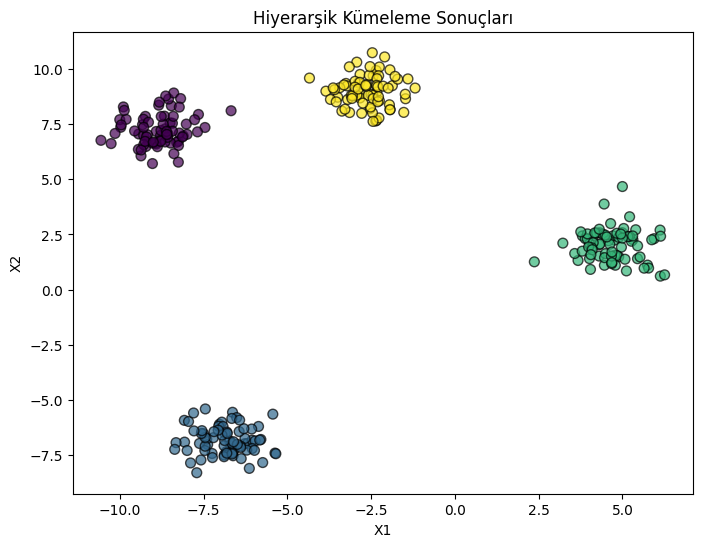

In [96]:
#sonuçları küme renkleriyle görselleştirme
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=labels,cmap="viridis",s=50,alpha=0.7, edgecolors="k")
plt.title("Hiyerarşik Kümeleme Sonuçları")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

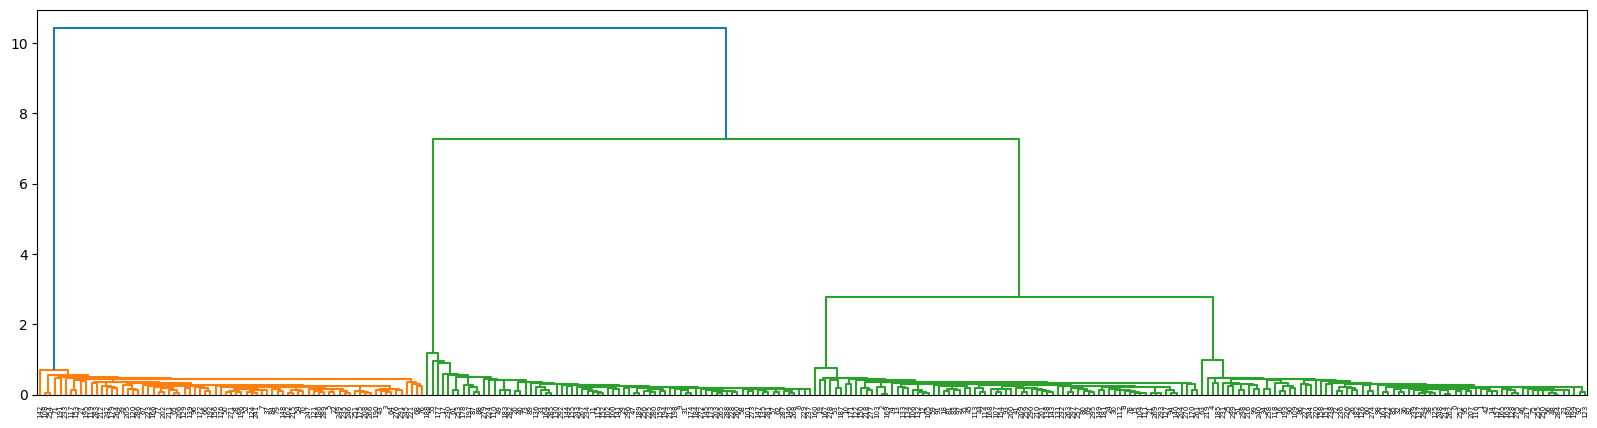

In [97]:
#dendogram
baglanti_matrisi=linkage(X)

plt.figure(figsize=(20,5))
dendrogram(baglanti_matrisi)
plt.show()

BOYUT İNDİRGEME: PCA


In [98]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [107]:
iris=load_iris()
X=iris.data
y=iris.target

In [115]:
iris = load_iris()
X = iris.data
y=iris.target
pca=PCA(n_components=2)
X_pca =pca.fit_transform(X)

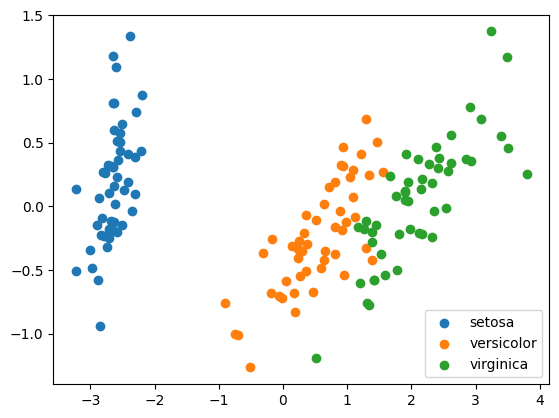

In [116]:
#PCA dönüşümü sonrası veri görselleştirme
plt.figure()
for i in range(len(iris.target_names)):
  plt.scatter(X_pca[y==i,0],X_pca[y==i,1] ,label=iris.target_names[i])

plt.legend()

##Cross Validation

In [123]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold ,StratifiedKFold,LeaveOneOut

In [124]:
#örnek veri seti yükleme
X,y=load_iris(return_X_y=True)

In [128]:
model=LogisticRegression(max_iter=200)


In [140]:
#KFold
kfold=KFold(n_splits=5, shuffle=True)
kfold_scores=cross_val_score(model,X,y,cv=kfold,scoring="accuracy")
kfold_scores

array([1.        , 1.        , 0.96666667, 0.96666667, 0.9       ])

In [141]:
# Stratfied KFold
kfoldStratified=StratifiedKFold(n_splits=5, shuffle=True)
kfold_scores=cross_val_score(model,X,y,cv=kfoldStratified,scoring="accuracy")
kfold_scores

array([0.96666667, 0.96666667, 1.        , 0.96666667, 0.93333333])

In [145]:
# Leave_One_Out
leaveOneOut=LeaveOneOut()
loo=cross_val_score(model,X,y,cv=leaveOneOut,scoring="accuracy")
loo

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Hiperparametre Tuning

In [153]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [154]:
#örnek veri setini yükleyip eğitim ve test olarak ayırma
X, y= load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test=train_test_split(
    X, y,test_size=0.2, random_state=42, stratify=y

)



In [149]:
 #Her model için hiperparametre arama uzayını tanımlayacağız.

In [155]:
models_and_params = {
    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "grid_params": {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__metric": ["euclidean", "manhattan"]
        },
        "random_params": {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__metric": ["euclidean", "manhattan", "minkowski"]
        }
    },
    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(random_state=42))
        ]),
        "grid_params": {
            "model__max_depth": [2, 3, 4, 5, None],
            "model__min_samples_split": [2, 4, 6],
            "model__criterion": ["gini", "entropy"]
        },
        "random_params": {
            "model__max_depth": [2, 3, 4, 5, None],
            "model__min_samples_split": [2, 4, 6],
            "model__criterion": ["gini", "entropy"]
        }
    },
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=500, random_state=42))
        ]),
        "grid_params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"]
        },
        "random_params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"]
        }
    }
}

In [156]:
results = []

#  Grid Search ile en iyi parametreleri bulacağız.
#  Random Search ile en iyi parametreleri bulacağız.
#  En iyi modelleri test verisi üzerinde değerlendireceğiz.
for model_name, item in models_and_params.items():
    grid_search = GridSearchCV(
        estimator=item["pipeline"],
        param_grid=item["grid_params"],
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    grid_test_score = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))

    random_search = RandomizedSearchCV(
        estimator=item["pipeline"],
        param_distributions=item["random_params"],
        n_iter=4,
        cv=3,
        scoring="accuracy",
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    random_test_score = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))

    results.append({
        "Model": model_name,
        "Yöntem": "Grid Search",
        "CV En İyi Skor": round(grid_search.best_score_, 4),
        "Test Skoru": round(grid_test_score, 4),
        "En İyi Parametreler": str(grid_search.best_params_)
    })

    results.append({
        "Model": model_name,
        "Yöntem": "Random Search",
        "CV En İyi Skor": round(random_search.best_score_, 4),
        "Test Skoru": round(random_test_score, 4),
        "En İyi Parametreler": str(random_search.best_params_)
    })

# 7. Sonuçları özet tablo halinde yazdıracağız.
results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 24.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **la

,Model,Yöntem,CV En İyi Skor,Test Skoru,En İyi Parametreler
0,KNN,Grid Search,0.9693,0.9737,"{'model__metric': 'manhattan', 'model__n_neigh..."
1,KNN,Random Search,0.9671,0.9561,"{'model__n_neighbors': 5, 'model__metric': 'mi..."
2,Decision Tree,Grid Search,0.9363,0.9386,"{'model__criterion': 'gini', 'model__max_depth..."
3,Decision Tree,Random Search,0.9296,0.9123,"{'model__min_samples_split': 2, 'model__max_de..."
4,Logistic Regression,Grid Search,0.9802,0.9737,"{'model__C': 0.1, 'model__penalty': 'l2'}"
5,Logistic Regression,Random Search,0.9802,0.9825,"{'model__penalty': 'l2', 'model__C': 1}"
